# Varer på salg

oppgave 3

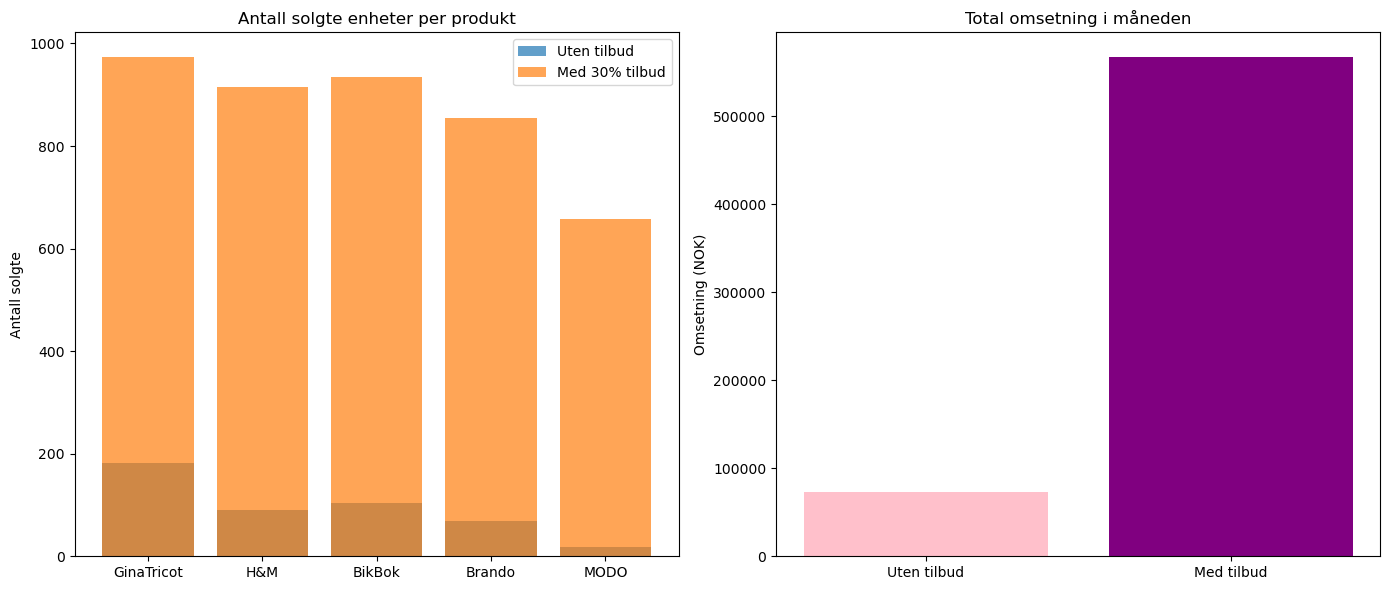

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt


class Product:
    def __init__(self, name, price, base_prob):
        self.name = name
        self.price = price
        self.base_prob = base_prob  # Basissjanse for kjøp


def logistic_increase(tilbudsprosent):
    return 1 / (1 + np.exp(-tilbudsprosent))


days_in_month = 30

# Definer produktene
products = [
    Product('GinaTricot', 99, 0.12),
    Product('H&M', 129, 0.07), 
    Product('BikBok', 199, 0.06),
    Product('Brando', 249, 0.04),
    Product('MODO', 300, 0.02)
]

# Antall kunder per dag (gjennomsnitt)
lambda_kunder = 50  

# Kunde-budsjetter 
budget_mu = 599  # Gjennomsnittlig budsjett
budget_sigma = 100  # Standardavvik i budsjettet


base_prob = {product.name: product.base_prob for product in products}

# Simuler en måned med eller uten tilbud
def simulate_month(tilbud=False, tilbudsprosent=0.0):
    total_sales = {product.name: 0 for product in products}
    total_revenue = 0
    
    for day in range(days_in_month):
 
        customers_today = np.random.poisson(lambda_kunder)
        
        for _ in range(customers_today):
     
            customer_budget = np.random.normal(budget_mu, budget_sigma)
            
        
            for product in products:
               
                prob = base_prob[product.name]
                
             
                if tilbud:
                    prob += logistic_increase(tilbudsprosent) * (1 - base_prob[product.name])
                    price = product.price * (1 - tilbudsprosent)
                else:
                    price = product.price
                
              
                if random.random() < prob and customer_budget >= price:
                    total_sales[product.name] += 1
                    total_revenue += price
                    customer_budget -= price  # Oppdatere budsjettet etter kjøpet

    return total_sales, total_revenue

# Simulere måned med og uten tilbud
tilbud_prosent = 0.30  # 30% tilbud på produkter
sales_without_discount, revenue_without_discount = simulate_month(tilbud=False)
sales_with_discount, revenue_with_discount = simulate_month(tilbud=True, tilbudsprosent=tilbud_prosent)

# Plot resultatene
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot for salg
ax[0].bar(sales_without_discount.keys(), sales_without_discount.values(), alpha=0.7, label='Uten tilbud')
ax[0].bar(sales_with_discount.keys(), sales_with_discount.values(), alpha=0.7, label='Med 30% tilbud')
ax[0].set_title('Antall solgte enheter per produkt')
ax[0].set_ylabel('Antall solgte')
ax[0].legend()

# Plot for omsetning
ax[1].bar(['Uten tilbud', 'Med tilbud'], [revenue_without_discount, revenue_with_discount], color=['pink', 'purple'])
ax[1].set_title('Total omsetning i måneden')
ax[1].set_ylabel('Omsetning (NOK)')

plt.tight_layout()
plt.show()

# Resultat 

... ikke ferdig med oppgaven 
